# 30-Day Hospital Readmission Prediction (Diabetic Patients)

### Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv("diabetic_data.csv")

print("Shape:", df_raw.shape)

df_raw.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df_raw.info()

df_raw.dtypes.value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

object    37
int64     13
Name: count, dtype: int64

### Data Cleaning

In [ ]:
# Replace missing values with NaN
df = df_raw.replace("?", np.nan)

# Summary statistics for all columns
summary = df.describe(include="all").transpose()

summary.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,99493,5,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,3197,9,[75-100),1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


### EDA: Missing Values and Outliers

In [ ]:
# Compute missing-value rate per column
missing_pct = df.isna().mean().sort_values(ascending=False)

missing_pct.head(20)

weight               0.968585
max_glu_serum        0.947468
A1Cresult            0.832773
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
encounter_id         0.000000
troglitazone         0.000000
tolbutamide          0.000000
pioglitazone         0.000000
rosiglitazone        0.000000
acarbose             0.000000
miglitol             0.000000
citoglipton          0.000000
tolazamide           0.000000
examide              0.000000
glipizide            0.000000
dtype: float64

### Feature Engineering and Data Quality

In [ ]:
df = df.copy()

# Identify ID-like columns if present
id_cols = [c for c in ["encounter_id", "patient_nbr"] if c in df.columns]
if id_cols:
    before = df.shape[0]
    df = df.drop_duplicates(subset=id_cols)
    print(f"Dropped duplicate rows by {id_cols}: {before - df.shape[0]}")

# Flag inconsistent gender as missing
if "gender" in df.columns:
    df.loc[df["gender"] == "Unknown/Invalid", "gender"] = np.nan

# Total prior visits across care settings
visit_cols = [c for c in ["number_outpatient", "number_inpatient", "number_emergency"] if c in df.columns]
if visit_cols:
    df["prior_visits"] = df[visit_cols].fillna(0).sum(axis=1)

# Total medications: count of non-"No" status across med columns
med_status_values = {"No", "Steady", "Up", "Down"}
candidate_cols = df.select_dtypes(include=["object"]).columns
med_cols = []
for col in candidate_cols:
    values = set(df[col].dropna().unique())
    if values and values.issubset(med_status_values):
        med_cols.append(col)

if med_cols:
    df["total_meds"] = (df[med_cols] != "No").sum(axis=1)

print("Engineered columns:", [c for c in ["prior_visits", "total_meds"] if c in df.columns])

Dropped duplicate rows by ['encounter_id', 'patient_nbr']: 0
Engineered columns: ['prior_visits', 'total_meds']


### EDA: Readmission by Demographics, Visits, and Labs

In [ ]:
# Helper function to compute readmission rate for a grouping column
def plot_readmit_rate(group_col, title, order=None):
    subset = df[df[group_col].notna()].copy()

    # Compute rate of <30 readmission per group
    rate = subset.groupby(group_col)["readmitted"].apply(lambda s: (s == "<30").mean())
    if order is not None:
        rate = rate.reindex(order)
    rate = rate.dropna()
    return rate

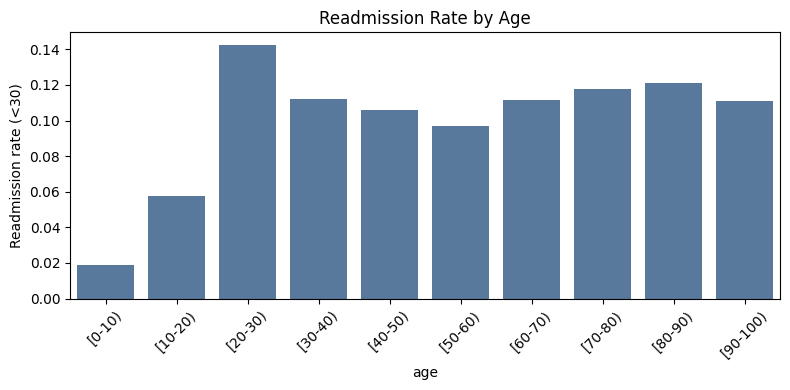

In [ ]:
# Plot readmission rate by age bucket 
if "age" in df.columns:
    age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)", 
                 "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]
    
    age_categories = [c for c in age_order if c in df["age"].unique()]
    # Compute readmission rate by age bucket
    rate = plot_readmit_rate("age", "Readmission Rate by Age", order=age_categories)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=rate.index.astype(str), y=rate.values, color="#4C78A8")
    plt.title("Readmission Rate by Age")
    plt.ylabel("Readmission rate (<30)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

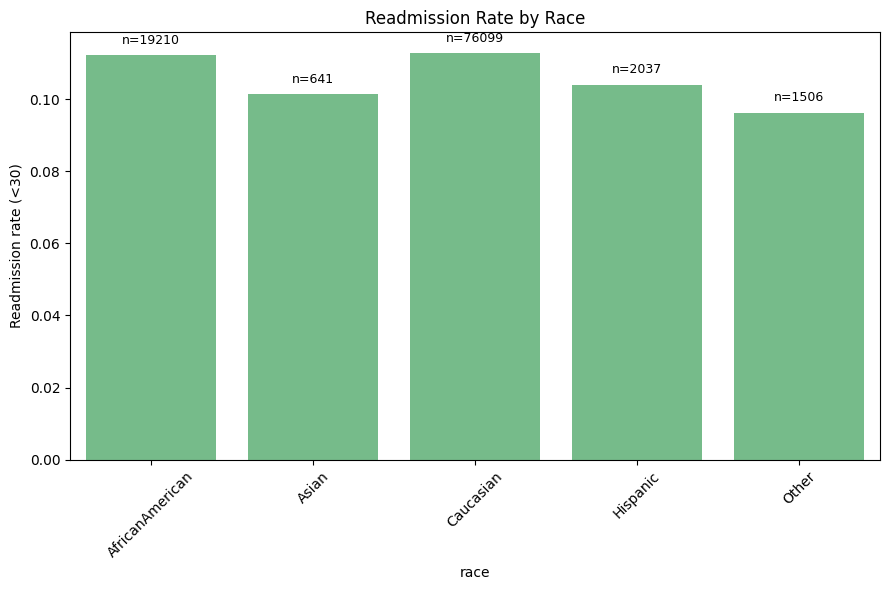

In [ ]:
# Plot readmission rate by race 
if "race" in df.columns:
    # Compute readmission rate by race
    rate = plot_readmit_rate("race", "Readmission Rate by Race")
    # Compute counts for each race category
    counts = df["race"].value_counts().reindex(rate.index)

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(x=rate.index.astype(str), y=rate.values, color="#6BC685")
    plt.title("Readmission Rate by Race")
    plt.ylabel("Readmission rate (<30)")
    plt.xticks(rotation=45)

    y_offset = max(rate.values) * 0.02 if len(rate) else 0.0

    # Add count labels above each bar
    for i, (val, cnt) in enumerate(zip(rate.values, counts.values)):
        ax.text(i, val + y_offset, f"n={cnt}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

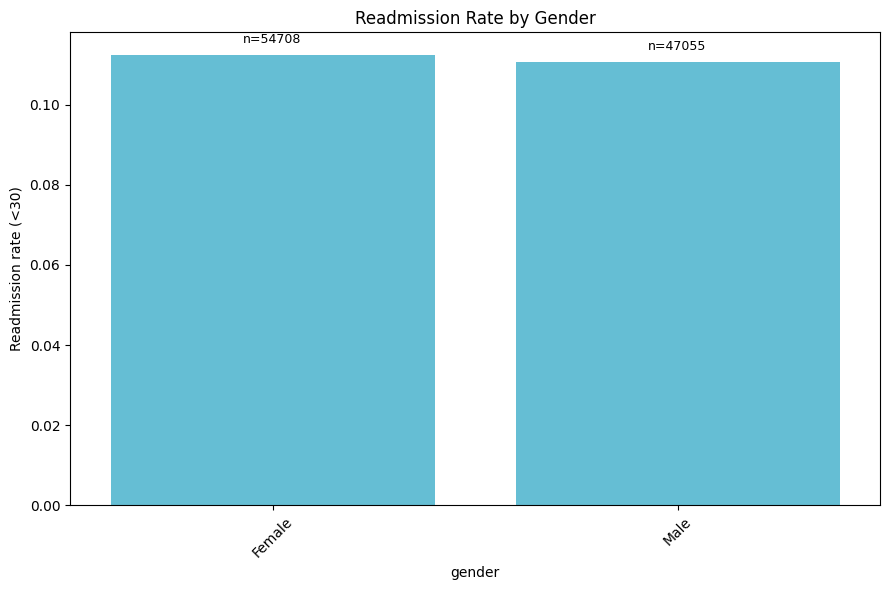

In [ ]:
# Plot readmission rate by gender 
if "gender" in df.columns:
    # Compute readmission rate by gender
    rate = plot_readmit_rate("gender", "Readmission Rate by Gender")
    # Compute counts for each gender category
    counts = df["gender"].value_counts().reindex(rate.index)

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(x=rate.index.astype(str), y=rate.values, color="#53C9E6")
    plt.title("Readmission Rate by Gender")
    plt.ylabel("Readmission rate (<30)")
    plt.xticks(rotation=45)

    y_offset = max(rate.values) * 0.02 if len(rate) else 0.0

    # Add count labels above each bar
    for i, (val, cnt) in enumerate(zip(rate.values, counts.values)):
        ax.text(i, val + y_offset, f"n={cnt}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

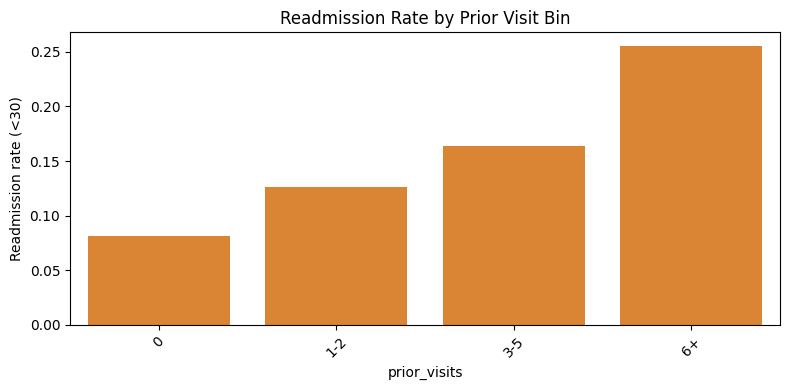

In [ ]:
# Plot readmission rate by prior visit bins
if "prior_visits" in df.columns:
    # Bin prior visits into interpretable ranges
    visit_bins = pd.cut(
        df["prior_visits"],
        bins=[-0.001, 0, 2, 5, float("inf")],
        labels=["0", "1-2", "3-5", "6+"],
        include_lowest=True,
    )
    # Compute readmission rate per visit bin
    visit_rate = df.groupby(visit_bins, observed=True)["readmitted"].apply(lambda s: (s == "<30").mean())

    plt.figure(figsize=(8, 4))
    sns.barplot(x=visit_rate.index.astype(str), y=visit_rate.values, color="#F58518")
    plt.title("Readmission Rate by Prior Visit Bin")
    plt.ylabel("Readmission rate (<30)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

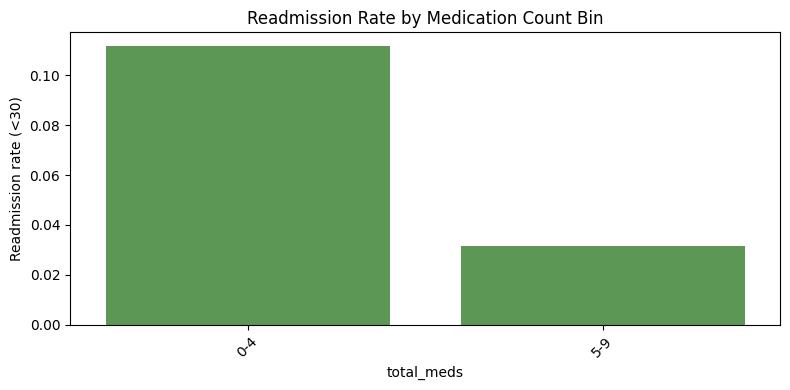

In [ ]:
# Plot readmission rate by medication count bins
if "total_meds" in df.columns:
    # Bin medication counts into interpretable ranges
    meds_bins = pd.cut(
        df["total_meds"],
        bins=[-0.001, 4, 9, 14, float("inf")],
        labels=["0-4", "5-9", "10-14", "15+"],
        include_lowest=True,
    )
    # Compute readmission rate per medication bin
    meds_rate = df.groupby(meds_bins, observed=True)["readmitted"].apply(lambda s: (s == "<30").mean())

    plt.figure(figsize=(8, 4))
    sns.barplot(x=meds_rate.index.astype(str), y=meds_rate.values, color="#54A24B")
    plt.title("Readmission Rate by Medication Count Bin")
    plt.ylabel("Readmission rate (<30)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

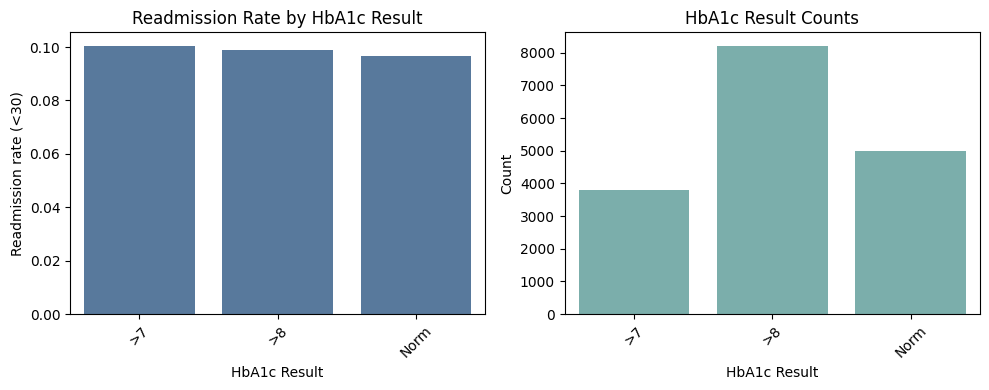

In [ ]:
# Plot HbA1c testing vs readmission rate
if "A1Cresult" in df.columns:
    a1c_df = df[df["A1Cresult"].notna()].copy()

    # Compute readmission rate by HbA1c category
    a1c_rate = a1c_df.groupby("A1Cresult", observed=True)["readmitted"].apply(lambda s: (s == "<30").mean())
    # Compute counts by HbA1c category
    a1c_count = a1c_df["A1Cresult"].value_counts().reindex(a1c_rate.index)

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Plot readmission rate
    sns.barplot(x=a1c_rate.index.astype(str), y=a1c_rate.values, color="#4C78A8", ax=axes[0])
    axes[0].set_title("Readmission Rate by HbA1c Result")
    axes[0].set_ylabel("Readmission rate (<30)")
    axes[0].set_xlabel("HbA1c Result")
    axes[0].tick_params(axis="x", rotation=45)

    # Plot category counts
    sns.barplot(x=a1c_count.index.astype(str), y=a1c_count.values, color="#72B7B2", ax=axes[1])
    axes[1].set_title("HbA1c Result Counts")
    axes[1].set_ylabel("Count")
    axes[1].set_xlabel("HbA1c Result")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### EDA: Correlation and Feature Relationships

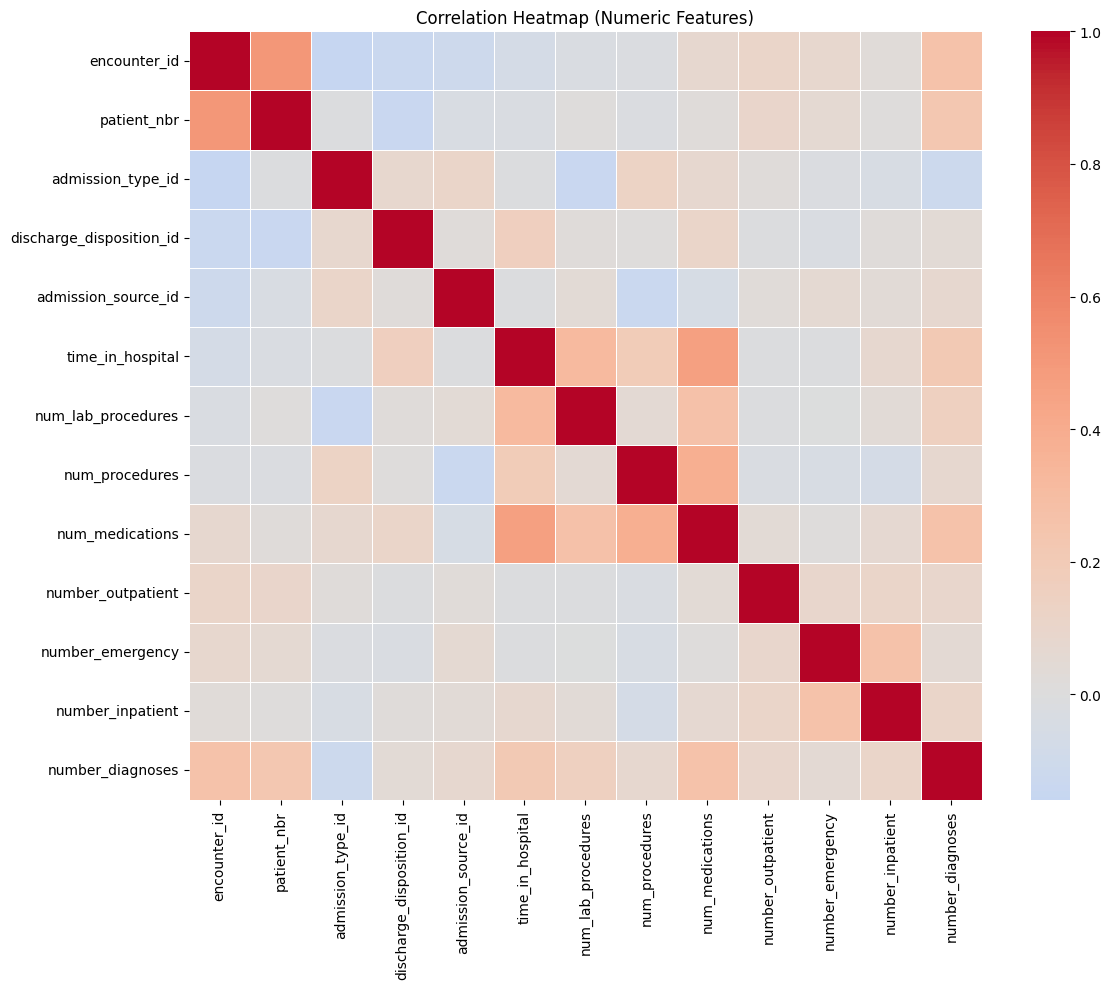

In [ ]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=["number"])

if not numeric_df.empty:
    # Compute correlation matrix
    corr = numeric_df.corr()
    # Create the plot
    plt.figure(figsize=(12, 10))

    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

### Train/Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

target_col = "readmitted"

# Binary target: <30 is positive, others are negative
label_map = {"<30": 1, ">30": 0, "NO": 0}

df = df.copy()

df[target_col] = df[target_col].map(label_map)

model_df = df.dropna(subset=[target_col])

# Drop identifier-like columns
drop_cols = [c for c in ["encounter_id", "patient_nbr"] if c in model_df.columns]

# Build feature matrix
X = model_df.drop(columns=[target_col] + drop_cols)

# Build target vector
y = model_df[target_col].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Readmitted rate (train):", y_train.mean())
print("Readmitted rate (valid):", y_valid.mean())

Train shape: (81412, 47)
Valid shape: (20354, 47)
Readmitted rate (train): 0.11160516877118852
Readmitted rate (valid): 0.11157512036946055


### Preprocessing Pipeline: Imputation, Encoding, Scaling

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier

# Identify categorical and numeric feature columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# Numeric pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Categorical pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 11
Categorical columns: 36


### Baseline Model Training

In [ ]:
# Baseline classifier with stratified random predictions
baseline_model = DummyClassifier(strategy="stratified")

# Build preprocessing and baseline pipeline
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", baseline_model),
    ],
)

baseline_pipe.fit(X_train, y_train)
print("Baseline fitted.")

Baseline fitted.


### Model Training: Decision-Tree Classifier Model

In [ ]:
# Decision tree classifier with grid search
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_model = DecisionTreeClassifier(random_state=42)

# Build preprocessing and tree pipeline
tree_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", tree_model),
    ]
)

# Hyperparameter grid for the tree
tree_param_grid = {
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 10, 20],
}

tree_search = GridSearchCV(
    tree_pipe,
    tree_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
 )

tree_search.fit(X_train, y_train)
print("Best tree params:", tree_search.best_params_)

Best tree params: {'model__max_depth': 8, 'model__min_samples_split': 20}


### Model Training: Logistic Regression Model

In [ ]:
# Logistic regression model
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
)

# Build preprocessing and model pipeline
log_reg_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", log_reg),
    ]
)

# Hyperparameter grid for regularization strength
log_reg_param_grid = {
    "model__C": [0.1, 1.0, 5.0],
}

log_reg_search = GridSearchCV(
    log_reg_pipe,
    log_reg_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
 )

log_reg_search.fit(X_train, y_train)
print("Best log-reg params:", log_reg_search.best_params_)

Best log-reg params: {'model__C': 0.1}


### Model Evaluation: Metrics and Curves

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    RocCurveDisplay,
 )

# Evaluate a model and store metrics and confusion matrix
def evaluate_model(name, model, X_val, y_val, results, confusion_results):
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_proba = None

    # Compute evaluation metrics
    metrics = {
        "auc": roc_auc_score(y_val, y_proba) if y_proba is not None else np.nan,
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
    }
    results[name] = metrics
    
    confusion_results[name] = confusion_matrix(y_val, y_pred)

    print(f"{name} metrics:")
    print(metrics)
    print()

results = {}
confusion_results = {}

best_tree = tree_search.best_estimator_
best_log_reg = log_reg_search.best_estimator_

for model_name, model in [
    ("Baseline", baseline_pipe),
    ("DecisionTree", best_tree),
    ("LogisticRegression", best_log_reg),
]:
    evaluate_model(model_name, model, X_valid, y_valid, results, confusion_results)

Baseline metrics:
{'auc': 0.49863733189975584, 'precision': 0.11217808817110432, 'recall': 0.11316600616468515, 'f1': 0.11266988163086365}

DecisionTree metrics:
{'auc': 0.6644646159583191, 'precision': 0.4064516129032258, 'recall': 0.02774108322324967, 'f1': 0.05193734542456719}

LogisticRegression metrics:
{'auc': 0.6559083825346371, 'precision': 0.17152542372881355, 'recall': 0.5570233377366799, 'f1': 0.26228488492639435}



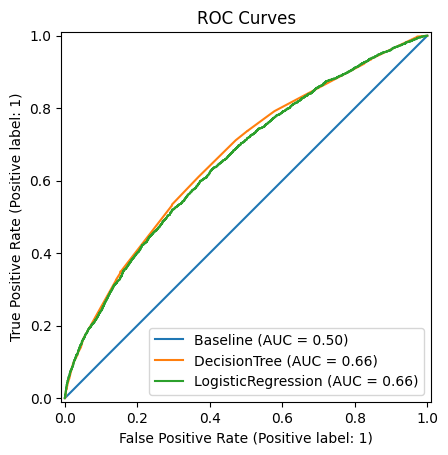

In [ ]:
# ROC curves
fig, ax = plt.subplots()
for model_name, model in [
    ("Baseline", baseline_pipe),
    ("DecisionTree", best_tree),
    ("LogisticRegression", best_log_reg),
]:
    if hasattr(model, "predict_proba"):
        RocCurveDisplay.from_estimator(model, X_valid, y_valid, name=model_name, ax=ax)
ax.set_title("ROC Curves")
plt.show()

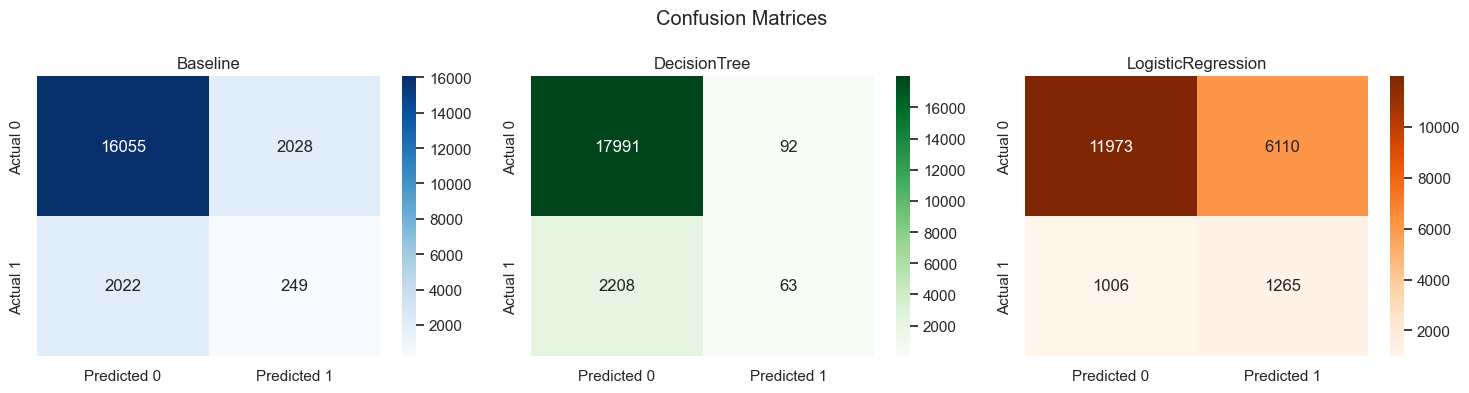

In [ ]:
# Confusion matrices
cmap_map = {
    "Baseline": "Blues",
    "DecisionTree": "Greens",
    "LogisticRegression": "Oranges",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, _) in zip(axes, [
    ("Baseline", baseline_pipe),
    ("DecisionTree", best_tree),
    ("LogisticRegression", best_log_reg),
]):
    # Fetch the confusion matrix for this model
    cm = confusion_results[model_name]

    # Draw a heatmap of the confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_map[model_name], ax=ax,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    ax.set_title(f'{model_name}')
plt.suptitle('Confusion Matrices')
plt.tight_layout()
plt.show()